In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from scipy.interpolate import interp1d
from matplotlib.ticker import MultipleLocator

In [2]:
arr0 = np.load("..\Data\Temperature\Bank0_Nominal_Sweep_4.npy")
arr1 = np.load("..\Data\Temperature\Bank0_T40_Sweep_4.npy")
arr2 = np.load("..\Data\Temperature\Bank0_T70_Sweep_4.npy")
print(arr0.shape)
arr0_DL_R = np.mean(arr0[:,1:-2],axis=1)
arr1_DL_R = np.mean(arr1[:,1:-2],axis=1)
arr2_DL_R = np.mean(arr2[:,1:-2],axis=1)

arr0_RL_R = np.mean(arr0[:,0:64:63],axis=1)
arr1_RL_R = np.mean(arr1[:,0:64:63],axis=1)
arr2_RL_R = np.mean(arr2[:,0:64:63],axis=1)

arr1_DL_R_C = arr1_DL_R*(np.mean(arr0_RL_R))/arr1_RL_R
arr2_DL_R_C = arr2_DL_R*(np.mean(arr0_RL_R))/arr2_RL_R

arr1_DL = arr1_DL_R[::-1]*-2
arr2_DL = arr2_DL_R[::-1]*-2

ideal_mac = np.arange(0,257,4)
m, c = np.polyfit(arr0_DL_R[::-1],ideal_mac , 1)
print(m,c)
arr0_DL = arr0_DL_R[::-1]*m + c
arr1_DL_C = arr1_DL_R_C[::-1]*m + c
arr2_DL_C = arr2_DL_R_C[::-1]*m + c


(65, 64)
-1.9295597121948347 -0.30866446352228577


In [4]:
arr2_DL_R.shape 

(65,)

In [5]:
print(arr2[:,0:64:63])
print(arr2_RL_R)

[[-138 -138]
 [-138 -138]
 [-138 -138]
 [-138 -139]
 [-138 -138]
 [-138 -139]
 [-138 -139]
 [-138 -139]
 [-138 -140]
 [-139 -139]
 [-138 -139]
 [-139 -139]
 [-139 -139]
 [-138 -139]
 [-139 -139]
 [-139 -139]
 [-138 -139]
 [-139 -140]
 [-139 -139]
 [-138 -140]
 [-139 -139]
 [-139 -140]
 [-138 -139]
 [-139 -140]
 [-139 -140]
 [-139 -140]
 [-139 -140]
 [-139 -140]
 [-139 -140]
 [-139 -139]
 [-139 -139]
 [-139 -140]
 [-139 -140]
 [-139 -140]
 [-140 -140]
 [-139 -140]
 [-139 -140]
 [-139 -140]
 [-139 -140]
 [-140 -140]
 [-139 -140]
 [-140 -140]
 [-140 -140]
 [-140 -140]
 [-139 -140]
 [-140 -140]
 [-140 -140]
 [-139 -140]
 [-139 -140]
 [-139 -140]
 [-139 -140]
 [-139 -140]
 [-139 -140]
 [-139 -140]
 [-140 -140]
 [-140 -140]
 [-139 -140]
 [-139 -140]
 [-140 -140]
 [-139 -140]
 [-139 -140]
 [-139 -140]
 [-139 -140]
 [-139 -140]
 [-139 -140]]
[-138.  -138.  -138.  -138.5 -138.  -138.5 -138.5 -138.5 -139.  -139.
 -138.5 -139.  -139.  -138.5 -139.  -139.  -138.5 -139.5 -139.  -139.
 -139.  -139.5

In [4]:
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams['font.family'] = 'Times New Roman'   # or 'Times New Roman', 'DejaVu Sans', etc.
mpl.rcParams['font.size'] = 12

# Axis-specific defaults
mpl.rcParams['axes.titlesize'] = 12
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12
mpl.rcParams['legend.fontsize'] = 12

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


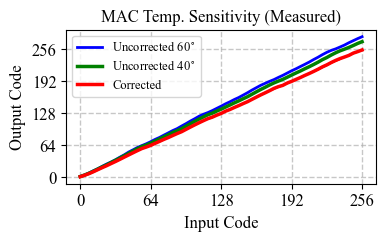

In [6]:
x_axis = np.arange(0,257,4)
fig, ax = plt.subplots(figsize=(4, 2))
plt.title("MAC Temp. Sensitivity (Measured)")
plt.ylabel("Output Code",fontsize = 12)
plt.xlabel("Input Code",fontsize = 12)
plt.legend()
plt.plot(x_axis,arr2_DL[0:],color = "b",linewidth=2,label="Uncorrected 60$^{\circ}$")
plt.plot(x_axis,arr1_DL[0:],color = "g",linewidth=2.5,label="Uncorrected 40$^{\circ}$")
plt.plot(x_axis,arr1_DL_C[0:],color = "r",linewidth=2.5,label="Corrected")
plt.legend(fontsize = 9)
plt.plot(x_axis,arr2_DL_C[0:],color = "r",linewidth=1)
plt.plot(x_axis,arr0_DL[0:],color = "r",linewidth=1)
plt.yticks(np.arange(0, 300, 64))
plt.xticks(np.arange(0, 260, 64))
plt.grid(True)
ax.grid(True, which='major', linestyle='--', linewidth=1, alpha=0.7)
ax.grid(True, which='minor', linestyle=':', linewidth=1, alpha=0.5)
plt.savefig(r"D:\ISSCC_26\Graphs\temp_measured.jpg", dpi=800, bbox_inches="tight")
plt.show()